Buckling Composite Tool (Simple Supported Rectangular Sandwhich Composite Plate)

In [1]:
import numpy as np
import sympy as sp
from scipy.linalg import inv
import matplotlib.pyplot as ply
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import quad
from scipy.linalg import eig

# Definindo variáveis simbólicas
x, y, z = sp.symbols('x y z')


E_1 = [6080, 6080, 6080, 6080, 5.93, 6080, 6080, 6080, 6080]  # [daN/mm^2]
E_2 = [5825, 5825, 5825, 5825, 5.93, 5825, 5825, 5825, 5825]   # [daN/mm^2]
G_12 = [455, 455, 455, 455, 2.41, 455, 455, 455, 455, 455]  # [daN/mm^2]
v_12 = [0.07, 0.07, 0.07, 0.07, 0.23, 0.07, 0.07, 0.07, 0.07]
v_21 = [0.07, 0.07, 0.07, 0.07, 0.23, 0.07, 0.07, 0.07, 0.07]


# Definição das variáveis
a = 75 # [mm]  X axis
b = 270 # [mm]  Y axis

Fx = 0 # Corga por unidade de comprimento (Nx/a)
Fy = -(75/75) # Corga por unidade de comprimento (Ny/b)

T = [0.21, 0.21, 0.21, 0.21, 3.175, 0.21, 0.21, 0.21, 0.21]      # Espessura de cada lâmina, em [mm]

M = 3  # Ordem de iteração para o campo de deslocamento Nw

# Orientação das camadas do skin, em [°]
skin = [0, 45, 90, -45, 0, -45, 90, 45, 0]

n = len(skin)  # Número de camadas - skin


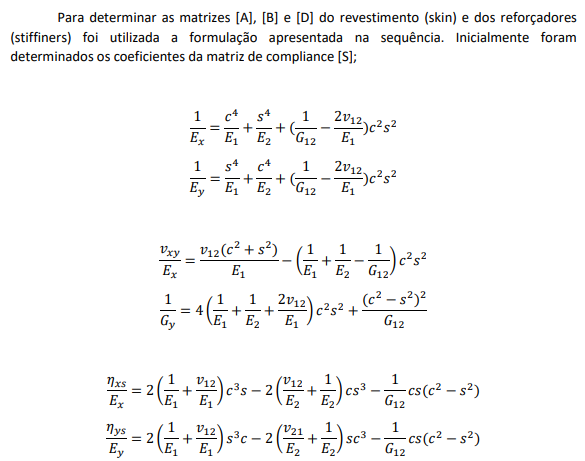

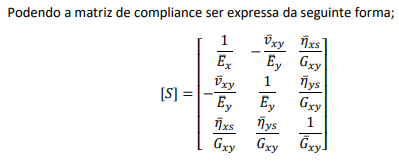

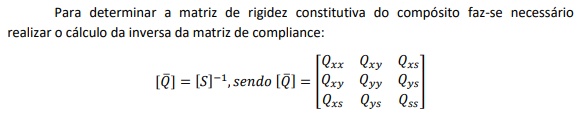

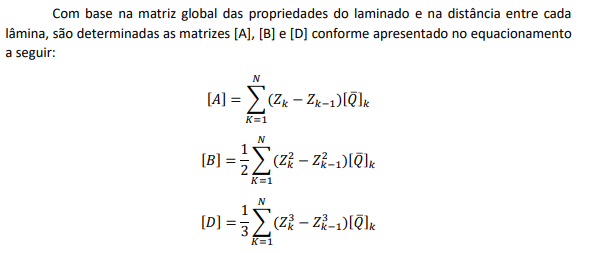

In [2]:
T = [0.21, 0.21, 0.21, 0.21, 3.175, 0.21, 0.21, 0.21, 0.21]  

# Verificação
if len(T) != n:
    raise ValueError(
        "O número de espessuras deve ser igual ao número de camadas."
    )

# Espessura total do laminado
h = sum(T)

print("Espessura total do laminado =", h, "mm")

# ============================================================
# POSIÇÃO Z DAS INTERFACES DAS CAMADAS
# ============================================================

Nz = []

# Interface inferior do laminado
z_atual = -h / 2

Nz.append(z_atual)

# Calcula as demais interfaces
for ti in T:
    z_atual += ti
    Nz.append(z_atual)

print("\nPosições das interfaces:")
for i, zi in enumerate(Nz):
    print(f"z{i} = {zi:.6f} mm")

# ============================================================
# POSIÇÃO DO CENTRO DE CADA CAMADA
# ============================================================

z_centro = []

for j in range(n):
    z_inf = Nz[j]
    z_sup = Nz[j + 1]

    z_centro.append(0.5 * (z_inf + z_sup))

print("\nPosição do centro de cada camada:")
for i, zi in enumerate(z_centro):
    print(f"Camada {i+1}: z = {zi:.6f} mm")

# ============================================================
# DIFERENÇAS ENTRE AS INTERFACES
# ============================================================

d = []
dd = []
ddd = []

for j in range(n):

    z_inf = Nz[j]
    z_sup = Nz[j + 1]

    # Integral de 1 dz
    d.append(z_sup - z_inf)

    # Integral de z dz
    dd.append(0.5 * (z_sup**2 - z_inf**2))

    # Integral de z^2 dz
    ddd.append((1/3) * (z_sup**3 - z_inf**3))



# Matrizes A, B e D do skin
A = np.zeros((3, 3))
B = np.zeros((3, 3))
D = np.zeros((3, 3))

t = 0

for i in range(n):
    theta_rad = np.radians(skin[i])  # Converte para radianos
    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)
    E_1_ply = E_1[i]
    E_2_ply = E_2[i]
    G_12_ply = G_12[i]
    v_12_ply = v_12[i]
    v_21_ply = v_21[i]
    t_ply = T[i]

    t += t_ply

    E_x = 1 / ((1 / E_1_ply) * (cos_theta**4) + (1 / E_2_ply) * (sin_theta**4) + ((1 / G_12_ply) - (2 * v_12_ply / E_1_ply)) * (cos_theta * sin_theta)**2)
    E_y = 1 / ((1 / E_1_ply) * (sin_theta**4) + (1 / E_2_ply) * (cos_theta**4) + ((1 / G_12_ply) - (2 * v_12_ply / E_1_ply)) * (cos_theta * sin_theta)**2)
    v_xy = E_x * ((v_12_ply / E_1_ply) * (cos_theta**4 + sin_theta**4) - ((1 / E_1_ply) + (1 / E_2_ply) - (1 / G_12_ply)) * ((cos_theta**2) * (sin_theta**2)))
    G_xy = 1 / (4 * ((1 / E_1_ply) + (1 / E_2_ply) + (2 * v_12_ply / E_1_ply)) * ((cos_theta**2) * (sin_theta**2)) + (1 / G_12_ply) * ((cos_theta**2 - sin_theta**2)**2))
    
    etha_E_x = (2 * ((1 / E_1_ply) + (v_12_ply / E_1_ply)) * (cos_theta**3) * sin_theta) - (2 * ((v_12_ply / E_1_ply) + (1 / E_2_ply)) * cos_theta * (sin_theta**3)) - (1 / G_12_ply) * cos_theta * sin_theta * ((cos_theta**2) - (sin_theta**2))
    etha_E_y = (2 * ((1 / E_1_ply) + (v_12_ply / E_1_ply)) * (sin_theta**3) * cos_theta) - (2 * ((v_12_ply / E_1_ply) + (1 / E_2_ply)) * sin_theta * (cos_theta**3)) + (1 / G_12_ply) * cos_theta * sin_theta * ((cos_theta**2) - (sin_theta**2))

    S_xx = np.array([[1 / E_x, -v_xy / E_x, etha_E_x], [-v_xy / E_x, 1 / E_y, etha_E_y], [etha_E_x, etha_E_y, 1 / G_xy]])
    Q_xx = inv(S_xx)

    A += d[i] * Q_xx
    B += dd[i] * Q_xx
    D += ddd[i] * Q_xx


A_inverse = inv(A)

t_equi = t
    
Ex_equi = 1/(A_inverse[0][0]*t)

Ey_equi = 1/(A_inverse[1][1]*t)

Gxy_equi = 1/(A_inverse[2][2]*t)

Vxy_equi = -A_inverse[0][1]/A_inverse[0][0]

Alphaxs_equi = A_inverse[0][2]/A_inverse[0][0]

Alphays_equi = A_inverse[1][2]/A_inverse[1][1]

print(f'\n  Matrix A \n {A}\n')

if A[0][2]<10e-5 and A[1][2]<10e-5:
    print('There is NOT coupling between Shear and Bending effects !!! \n\n')
else:
    print('There is coupling between Shear and Bending effects !!! \n\n')


print(f' Matrix B \n {B}\n')

if all(B[i][j] < 10e-5 for i in range(3) for j in range(3)):
    print('There is NOT coupling between Membrane and Bending effects !!! \n\n')
else:
    print('There is coupling between Membrane and Bending effects !!! \n\n')
    

print(f'Matrix D \n {D}\n')

if D[0][2]<10e-5 and D[1][2]<10e-5:
    print('There is NOT coupling between Twist and Bending effects !!! \n\n')
else:
    print('There is coupling between Twist and Bending effects !!! \n\n')

print('MEMBRANE PROPERTIES\n')

print(skin)

print('\n')

print(f't equivalent: {t_equi}\n')

print(f'Ex equivalent: {Ex_equi}\n')

print(f'Ey equivalent: {Ey_equi}\n')

print(f'Gxy equivalent: {Gxy_equi}\n')

print(f'Vxy equivalent: {Vxy_equi}\n')

print(f'Alphaxs equivalent: {Alphaxs_equi}\n')

print(f'Alphays equivalent: {Alphays_equi}\n')

#CHECK


Espessura total do laminado = 4.8549999999999995 mm

Posições das interfaces:
z0 = -2.427500 mm
z1 = -2.217500 mm
z2 = -2.007500 mm
z3 = -1.797500 mm
z4 = -1.587500 mm
z5 = 1.587500 mm
z6 = 1.797500 mm
z7 = 2.007500 mm
z8 = 2.217500 mm
z9 = 2.427500 mm

Posição do centro de cada camada:
Camada 1: z = -2.322500 mm
Camada 2: z = -2.112500 mm
Camada 3: z = -1.902500 mm
Camada 4: z = -1.692500 mm
Camada 5: z = 0.000000 mm
Camada 6: z = 1.692500 mm
Camada 7: z = 1.902500 mm
Camada 8: z = 2.112500 mm
Camada 9: z = 2.322500 mm

  Matrix A 
 [[ 8.10966757e+03  2.65040231e+03 -1.17239551e-13]
 [ 2.65040231e+03  8.10966757e+03  1.24344979e-13]
 [-1.17239551e-13  1.24344979e-13  2.72963082e+03]]

There is NOT coupling between Shear and Bending effects !!! 


 Matrix B 
 [[-4.54747351e-13 -1.98951966e-13  0.00000000e+00]
 [-1.98951966e-13 -4.54747351e-13  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.13686838e-13]]

There is NOT coupling between Membrane and Bending effects !!! 


Matrix D 

In [3]:
# Orientação das camadas dos reforçadores, em [°]
stiffener = [45, -45, 0, 90, 90, 0, -45, 45]
n_stiffener = len(stiffener)  # Número de camadas - reforçador

Nz_stiffener = []
for i in range(1, n_stiffener + 2):
    Nz_stiffener.append((i - ((n_stiffener/2) + 1)) * t)

# Diferenças entre espessuras nos reforçadores
d_stiffener = []
dd_stiffener = []
ddd_stiffener = []
for j in range(1, n_stiffener + 1):
    k = j - 1
    d_stiffener.append(Nz_stiffener[j] - Nz_stiffener[k])
    dd_stiffener.append(0.5 * (Nz_stiffener[j]**2 - Nz_stiffener[k]**2))
    ddd_stiffener.append((1/3) * (Nz_stiffener[j]**3 - Nz_stiffener[k]**3))

# Matrizes A, B e D dos reforçadores
A_stiffener = np.zeros((3, 3))
B_stiffener = np.zeros((3, 3))
D_stiffener = np.zeros((3, 3))

for i in range(n_stiffener):
    theta_rad_stiffener = np.radians(stiffener[i])  # Converte para radianos
    cos_theta_stiffener = np.cos(theta_rad_stiffener)
    sin_theta_stiffener = np.sin(theta_rad_stiffener)
    E_1_ply = E_1[i]
    E_2_ply = E_2[i]
    G_12_ply = G_12[i]
    v_12_ply = v_12[i]
    v_21_ply = v_21[i]
    t_ply = T[i]

    E_x_stiffener = 1 / ((1 / E_1_ply) * (cos_theta_stiffener**4) + (1 / E_2_ply) * (sin_theta_stiffener**4) + ((1 / G_12_ply) - (2 * v_12_ply / E_1_ply)) * (cos_theta_stiffener * sin_theta_stiffener)**2)
    E_y_stiffener = 1 / ((1 / E_1_ply) * (sin_theta_stiffener**4) + (1 / E_2_ply) * (cos_theta_stiffener**4) + ((1 / G_12_ply) - (2 * v_12_ply / E_1_ply)) * (cos_theta_stiffener * sin_theta_stiffener)**2)
    v_xy_stiffener = E_x_stiffener * ((v_12_ply / E_1_ply) * (cos_theta_stiffener**4 + sin_theta_stiffener**4) - ((1 / E_1_ply) + (1 / E_2_ply) - (1 / G_12_ply)) * ((cos_theta_stiffener**2) * (sin_theta_stiffener**2)))
    G_xy_stiffener = 1 / (4 * ((1 / E_1_ply) + (1 / E_2_ply) + (2 * v_12_ply / E_1_ply)) * ((cos_theta_stiffener**2) * (sin_theta_stiffener**2)) + (1 / G_12_ply) * ((cos_theta_stiffener**2 - sin_theta_stiffener**2)**2))

    etha_E_x_stiffener = (2 * ((1 / E_1_ply) + (v_12_ply / E_1_ply)) * (cos_theta_stiffener**3) * sin_theta_stiffener) - (2 * ((v_12_ply / E_1_ply) + (1 / E_2_ply)) * cos_theta_stiffener * (sin_theta_stiffener**3)) - (1 / G_12_ply) * cos_theta_stiffener * sin_theta_stiffener * ((cos_theta_stiffener**2) - (sin_theta_stiffener**2))
    etha_E_y_stiffener = (2 * ((1 / E_1_ply) + (v_12_ply / E_1_ply)) * (sin_theta_stiffener**3) * cos_theta_stiffener) - (2 * ((v_12_ply / E_1_ply) + (1 / E_2_ply)) * sin_theta_stiffener * (cos_theta_stiffener**3)) + (1 / G_12_ply) * cos_theta_stiffener * sin_theta_stiffener * ((cos_theta_stiffener**2) - (sin_theta_stiffener**2))

    S_xx_stiffener = np.array([[1 / E_x_stiffener, -v_xy_stiffener / E_x_stiffener, etha_E_x_stiffener], [-v_xy_stiffener / E_x_stiffener, 1 / E_y_stiffener, etha_E_y_stiffener], [etha_E_x_stiffener, etha_E_y_stiffener, 1 / G_xy_stiffener]])
    Q_xx_stiffener = inv(S_xx_stiffener)
    

    A_stiffener += d_stiffener[i] * Q_xx_stiffener
    B_stiffener += dd_stiffener[i] * Q_xx_stiffener
    D_stiffener += ddd_stiffener[i] * Q_xx_stiffener

    A_stiffener_inverse = inv(A_stiffener)

    Ex_equi_stiff = 1/(A_stiffener_inverse[0][0]*t)

    Ey_equi_stiff = 1/(A_stiffener_inverse[1][1]*t)

    Gxy_equi_stiff = 1/(A_stiffener_inverse[2][2]*t)

    Vxy_equi_stiff = -A_stiffener_inverse[0][1]/A_stiffener_inverse[0][0]

    Alphaxs_equi_stiff = A_stiffener_inverse[0][2]/A_stiffener_inverse[0][0]

    Alphays_equi_stiff = A_stiffener_inverse[1][2]/A_stiffener_inverse[1][1]
    

# Resultados finais

print(f' Matrix A stiffener \n {A_stiffener}\n')

if A_stiffener[0][2]<10e-5 and A_stiffener[1][2]<10e-5:
    print('There is NOT coupling between Shear and Bending effects !!! \n\n')
else:
    print('There is coupling between Shear and Bending effects !!! \n\n')


print(f' Matrix B stiffener \n {B_stiffener}\n')

if all(B_stiffener[i][j] < 10e-5 for i in range(3) for j in range(3)):
    print('There is NOT coupling between Membrane and Bending effects !!! \n\n')
else:
    print('There is coupling between Membrane and Bending effects !!! \n\n')
    

print(f'Matrix D stiffener\n {D_stiffener}\n')

if D_stiffener[0][2]<10e-5 and D_stiffener[1][2]<10e-5:
    print('There is NOT coupling between Twist and Bending effects !!! \n\n')
else:
    print('There is coupling between Twist and Bending effects !!! \n\n')



print(f'Ex equivalent stiffener: {Ex_equi_stiff}\n')

print(f'Ey equivalent stiffener: {Ey_equi_stiff}\n')

print(f'Gxy equivalent stiffener: {Gxy_equi_stiff}\n')

print(f'Vxy equivalent stiffener: {Vxy_equi_stiff}\n')

print(f'Alphaxs equivalent stiffener: {Alphaxs_equi_stiff}\n')

print(f'Alphays equivalent stiffener: {Alphays_equi}\n')

 Matrix A stiffener 
 [[ 1.58644834e+05  5.91870993e+04 -1.13686838e-12]
 [ 5.91870993e+04  1.57400969e+05  1.64845915e-12]
 [-1.13686838e-12  1.64845915e-12  6.07322393e+04]]

There is NOT coupling between Shear and Bending effects !!! 


 Matrix B stiffener 
 [[-6.89006183e+04 -4.81123662e+03  3.63797881e-12]
 [-4.81123662e+03 -7.19200989e+04 -3.63797881e-12]
 [ 3.63797881e-12 -3.63797881e-12 -5.33400510e+03]]

There is NOT coupling between Membrane and Bending effects !!! 


Matrix D stiffener
 [[19080294.00393585 11941171.85872272    87957.47015251]
 [11941171.85872272 18953244.32482667    87957.47015251]
 [   87957.47015251    87957.47015251 12160795.11774293]]

There is coupling between Twist and Bending effects !!! 


Ex equivalent stiffener: 28092.451969726124

Ey equivalent stiffener: 27872.191419480663

Gxy equivalent stiffener: 12509.215094062049

Vxy equivalent stiffener: 0.37602753978770254

Alphaxs equivalent stiffener: 2.89258956275556e-17

Alphays equivalent stiffener: 

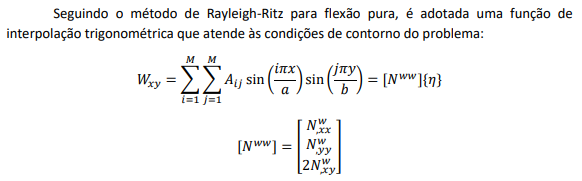

In [4]:
linha1 = np.concatenate((A, B), axis=1)
linha2 = np.concatenate((B, D), axis=1)
ABD = np.concatenate((linha1, linha2), axis=0)

ABD1 = sp.Matrix(ABD)
ABD1

Matrix([
[      8109.6675653267,       2650.4023119995, -1.17239551400417e-13, -4.54747350886464e-13, -1.98951966012828e-13,                  0.0],
[      2650.4023119995,       8109.6675653267,  1.24344978758018e-13, -1.98951966012828e-13, -4.54747350886464e-13,                  0.0],
[-1.17239551400417e-13,  1.24344978758018e-13,      2729.63081975303,                   0.0,                   0.0, 1.13686837721616e-13],
[-4.54747350886464e-13, -1.98951966012828e-13,                   0.0,      34015.4198012143,      9996.99330172946,     42.9909480815158],
[-1.98951966012828e-13, -4.54747350886464e-13,                   0.0,      9996.99330172946,      33824.4744601952,     42.9909480815166],
[                  0.0,                   0.0,  1.13686837721616e-13,      42.9909480815158,      42.9909480815166,     10310.9426039264]])

In [5]:
# Definir variáveis simbólicas
x = sp.symbols('x')
y = sp.symbols('y')

# Inicializando o campo de deslocamento w
w = np.zeros((M, M))
Nw = []

cont = 0
for i in range(1, M+1):
    for j in range(1, M+1):
        # Definir a expressão simbólica para w_ij
        w_ij = sp.sin((i * sp.pi * x) / a) * sp.sin((j * sp.pi * y) / b)
        Nw.append(w_ij)
        cont += 1

# Verificando os valores de Nw
Nw = sp.Matrix(Nw)
Nw

Matrix([
[  sin(pi*x/75)*sin(pi*y/270)],
[  sin(pi*x/75)*sin(pi*y/135)],
[   sin(pi*x/75)*sin(pi*y/90)],
[sin(2*pi*x/75)*sin(pi*y/270)],
[sin(2*pi*x/75)*sin(pi*y/135)],
[ sin(2*pi*x/75)*sin(pi*y/90)],
[  sin(pi*x/25)*sin(pi*y/270)],
[  sin(pi*x/25)*sin(pi*y/135)],
[   sin(pi*x/25)*sin(pi*y/90)]])

In [6]:
# Derivadas de w em relação a x e y
Nwxx = [sp.diff(w_ij, x, 2) for w_ij in Nw]  # Segunda derivada de w em relação a x
Nwyy = [sp.diff(w_ij, y, 2) for w_ij in Nw]  # Segunda derivada de w em relação a y
Nwxy = [sp.diff(sp.diff(w_ij, x), y) for w_ij in Nw]  # Derivada mista de w em relação a x e y

Nwx = [sp.diff(w_ij, x, 1) for w_ij in Nw]  # Segunda derivada de w em relação a x
Nwy = [sp.diff(w_ij, y, 1) for w_ij in Nw]  # Segunda derivada de w em relação a y
Nwyx = [sp.diff(sp.diff(w_ij, y), x) for w_ij in Nw]  # Derivada mista de w em relação a y e x

# Derivadas de primeiro ordem
Nwx = [sp.diff(w_ij, x) for w_ij in Nw]  # Derivada de w em relação a x
Nwy = [sp.diff(w_ij, y) for w_ij in Nw]  # Derivada de w em relação a y

# Convertendo listas de derivadas dentro das matrizes sympy
Nwxx_matrix = sp.Matrix(Nwxx)  # Converting list to Matrix
Nwyy_matrix = sp.Matrix(Nwyy)  # Converting list to Matrix
Nwxy_matrix = sp.Matrix(Nwxy)  # Converting list to Matrix

Nwx_matrix = sp.Matrix(Nwx)  # Converting list to Matrix
Nwy_matrix = sp.Matrix(Nwy)  # Converting list to Matrix
Nwyx_matrix = sp.Matrix(Nwyx)  # Converting list to Matrix


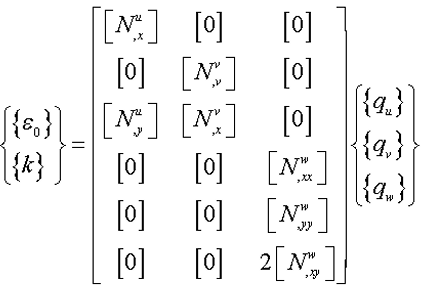

In [7]:
zeros = np.zeros((1, 9))
zeros= sp.Matrix(zeros)

# Matriz de derivadas (vetor de derivadas)
#Nwwuv1 = sp.Matrix([[Nux_matrix.T, zeros, zeros],[zeros, Nuy_matrix.T, zeros], [Nuy_matrix.T, Nux_matrix.T, zeros], [zeros, zeros, Nwxx_matrix.T], [zeros, zeros, Nwyy_matrix.T],[zeros, zeros, 2*Nwxy_matrix.T]])
Nwwuv1 = sp.Matrix([[Nwx_matrix.T, zeros, zeros],[zeros, Nwy_matrix.T, zeros], [Nwy_matrix.T, Nwx_matrix.T, zeros], [zeros, zeros, Nwxx_matrix.T], [zeros, zeros, Nwyy_matrix.T],[zeros, zeros, 2*Nwxy_matrix.T]])
Nwwuv1

Matrix([
[ pi*sin(pi*y/270)*cos(pi*x/75)/75,  pi*sin(pi*y/135)*cos(pi*x/75)/75, pi*sin(pi*y/90)*cos(pi*x/75)/75, 2*pi*sin(pi*y/270)*cos(2*pi*x/75)/75, 2*pi*sin(pi*y/135)*cos(2*pi*x/75)/75, 2*pi*sin(pi*y/90)*cos(2*pi*x/75)/75,  pi*sin(pi*y/270)*cos(pi*x/25)/25,  pi*sin(pi*y/135)*cos(pi*x/25)/25, pi*sin(pi*y/90)*cos(pi*x/25)/25,                               0.0,                               0.0,                             0.0,                                  0.0,                                  0.0,                                 0.0,                               0.0,                               0.0,                             0.0,                                     0.0,                                      0.0,                                   0.0,                                        0.0,                                        0.0,                                       0.0,                                     0.0,                                     0.0,                  

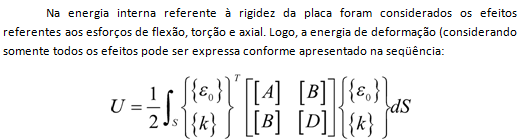

In [8]:
Kp_expr = sp.integrate(sp.integrate((Nwwuv1.T * ABD * Nwwuv1), (x, 0, a)), (y, 0, b))

Kp_expr

Matrix([
[     7488.25850461021*pi**2,                           0,                           0,                           0,        4.16851738312592e-13,                                                                                                                                    0,                                                                                                                                  0,                           0,                           0, -9.68805282910681e-14*pi**2,                                                                                                                                   0,                                                                                                                                  0,                           0,                                                                                                                        -9564.50334533783,                                                             

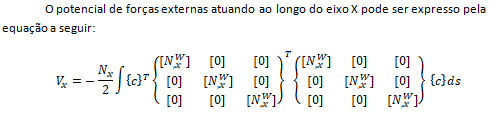

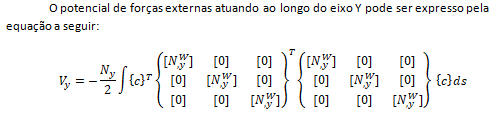

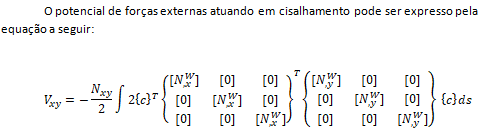

In [9]:
# Convertendo a lista para uma matriz do SymPy
Nwx_matrix = sp.Matrix(Nwx)
Nwy_matrix = sp.Matrix(Nwy)

Nnx = sp.Matrix([[Nwx_matrix.T, zeros, zeros], [zeros, Nwx_matrix.T, zeros],[zeros, zeros, Nwx_matrix.T]])
Nny = sp.Matrix([[Nwy_matrix.T, zeros, zeros], [zeros, Nwy_matrix.T, zeros],[zeros, zeros, Nwy_matrix.T]])

Kgx = Fx*(sp.integrate(sp.integrate(Nnx.T * Nnx, (x, 0, a)), (y, 0, b)))
Kgy = Fy*(sp.integrate(sp.integrate(Nny.T * Nny, (x, 0, a)), (y, 0, b)))


KG = Kgx + Kgy
KG
#Nnx

Matrix([
[-0.0694444444444444*pi**2,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0],
[                        0, -0.277777777777778*pi**2,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        0,            0,                         0,                        

In [10]:
import numpy as np

# Definindo as matrizes A e B como arrays NumPy
A = np.array(Kp_expr , dtype=np.float64)
B = np.array(KG, dtype=np.float64)

# Verificando se as matrizes são invertíveis
if np.linalg.det(B) != 0:  # Verifica se a matriz B é invertível
    # Calculando os autovalores e autovetores para o problema generalizado A v = lambda B v
    autovalores, autovetores = np.linalg.eig(np.linalg.inv(B) @ A)
    
    # Exibindo os resultados
    print("Autovalores:", autovalores)
    print("Autovetores:\n", autovetores)
else:
    print("A matriz B não é invertível!")

Autovalores: [-9.48815516e+05 -4.23724248e+05 -3.27214214e+05 -2.41196866e+05
 -1.07830922e+05 -1.09430212e+05 -1.48291941e+05 -4.23291544e+04
 -1.08899310e+05 -8.86851715e+04 -4.85403125e+04 -4.18870909e+04
 -4.34856830e+04 -3.09828383e+04 -6.36247812e+04 -1.37905312e+04
 -2.11869155e+04 -1.62857550e+04 -1.66486450e+04 -1.28102993e+04
 -1.18501325e+04 -1.84610795e+03 -3.19138499e+02 -3.54208965e+03
 -7.96970770e+03 -8.85522440e+02 -2.34605487e+02]
Autovetores:
 [[-1.15113615e-04  1.61517214e-16 -6.70141151e-16  1.12335775e-16
   9.55523588e-01  9.35455208e-01 -2.32998528e-17  2.06730092e-01
   1.76780483e-14 -1.61264919e-16  6.88868099e-17 -3.10779427e-16
  -8.65417943e-17 -1.01852734e-16  1.37792242e-17  3.20136114e-02
  -2.72245213e-17 -5.90433492e-17 -2.14149833e-18  6.66143125e-18
  -2.52613043e-18 -1.75545513e-19 -1.14674073e-21  1.85392403e-21
  -5.17707861e-24  2.55611793e-24  2.80991771e-25]
 [-1.83833087e-18  1.83187728e-16 -6.80656590e-17  5.02057699e-03
  -1.34412715e-17  2

In [11]:
# Carga crítica de flambagem (vetor diagonal do autovalor Ds)
Ny_cr = autovalores

# Calculando o valor mínimo absoluto da diagonal
Val = np.min(np.abs(Ny_cr))  # Valor absoluto mínimo
ind = np.argmin(np.abs(Ny_cr))  # Índice do valor absoluto mínimo

# Exibindo os resultados
print(f"Valor mínimo absoluto: {Val}")
print(f"Índice do valor mínimo absoluto: {ind}")

Valor mínimo absoluto: 234.6054872637108
Índice do valor mínimo absoluto: 26


In [12]:
Nw1 = sp.Matrix([[Nw.T, Nw.T, Nw.T]])
Nw1

Matrix([[sin(pi*x/75)*sin(pi*y/270), sin(pi*x/75)*sin(pi*y/135), sin(pi*x/75)*sin(pi*y/90), sin(2*pi*x/75)*sin(pi*y/270), sin(2*pi*x/75)*sin(pi*y/135), sin(2*pi*x/75)*sin(pi*y/90), sin(pi*x/25)*sin(pi*y/270), sin(pi*x/25)*sin(pi*y/135), sin(pi*x/25)*sin(pi*y/90), sin(pi*x/75)*sin(pi*y/270), sin(pi*x/75)*sin(pi*y/135), sin(pi*x/75)*sin(pi*y/90), sin(2*pi*x/75)*sin(pi*y/270), sin(2*pi*x/75)*sin(pi*y/135), sin(2*pi*x/75)*sin(pi*y/90), sin(pi*x/25)*sin(pi*y/270), sin(pi*x/25)*sin(pi*y/135), sin(pi*x/25)*sin(pi*y/90), sin(pi*x/75)*sin(pi*y/270), sin(pi*x/75)*sin(pi*y/135), sin(pi*x/75)*sin(pi*y/90), sin(2*pi*x/75)*sin(pi*y/270), sin(2*pi*x/75)*sin(pi*y/135), sin(2*pi*x/75)*sin(pi*y/90), sin(pi*x/25)*sin(pi*y/270), sin(pi*x/25)*sin(pi*y/135), sin(pi*x/25)*sin(pi*y/90)]])

In [13]:
Nw1 = sp.Matrix([[Nw.T, Nw.T, Nw.T]])

Mode = ind  # O modo de vibração

i = ind

displacement_field = -Nw1 @ autovetores[:, i]  # Multiplicação de matrizes/vetores  [:, i]

# Gerar a grade de x e y para a superfície
x = np.linspace(0, a, a)  # criando 100 pontos entre 0 e a 80 
y = np.linspace(0, b, b)  # criando 100 pontos entre 0 e b 40
X, Y = np.meshgrid(x, y)  # Criar uma grade para o gráfico

In [14]:
if displacement_field.size != X.size:
    displacement_field = np.resize(displacement_field, X.size)


Z = displacement_field.reshape(X.shape)

In [15]:
x = np.arange(0, a, 1)  # x variando de 0 até a
y = np.arange(0, b, 1)  # y variando de 0 até b

# Criando uma grade de coordenadas (x, y) usando meshgrid
X, Y = np.meshgrid(x, y)

# Substituindo na expressão fornecida para Z
Z_new = np.zeros((b, a))

if Fx==0 and Fy!=0:
    for i in range(b):
        for j in range(a):
            Z_new[i,j]=np.array(Z[i,j].evalf(subs={"x":i,"y":j}))
else:
    for i in range(b):
        for j in range(a):
            Z_new[i,j]=np.array(Z[i,j].evalf(subs={"y":i,"x":j}))



<Figure size 640x480 with 0 Axes>

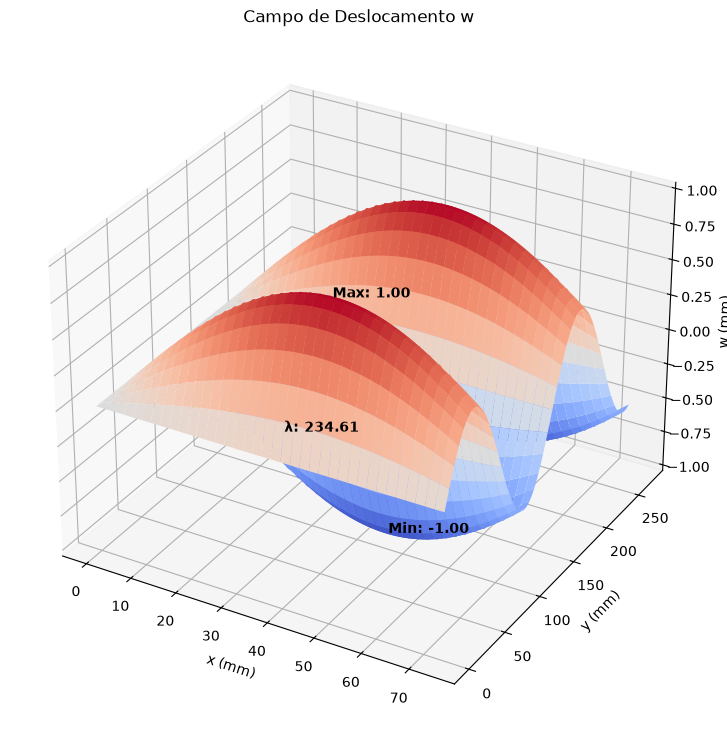

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Criar o gráfico 3D
fig = plt.figure()
fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície
ax.plot_surface(X, Y, Z_new, cmap='coolwarm')

# Calcular os valores máximo e mínimo de Z_new
Z_max = np.max(Z_new)
Z_min = np.min(Z_new)

# Obter as coordenadas para o valor máximo e mínimo
max_coord = np.unravel_index(np.argmax(Z_new), Z_new.shape)
min_coord = np.unravel_index(np.argmin(Z_new), Z_new.shape)

# Adicionar texto para o maior valor
ax.text(X[max_coord], Y[max_coord], Z_max, f'Max: {Z_max:.2f}', color='black', fontsize=10, weight='bold')

# Adicionar texto para o menor valor
ax.text(X[min_coord], Y[min_coord], Z_min, f'Min: {Z_min:.2f}', color='black', fontsize=10, weight='bold')

# Adicionar texto para o eigenvalue
ax.text(X[35, 35], Y[35, 35], Z_new[0, 0], f'λ: {Val:.2f}', color='black', fontsize=10, weight='bold')

# Adicionar rótulos aos eixos e título
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('w (mm)')
ax.set_title('Campo de Deslocamento w')

# Exibir o gráfico
plt.show()

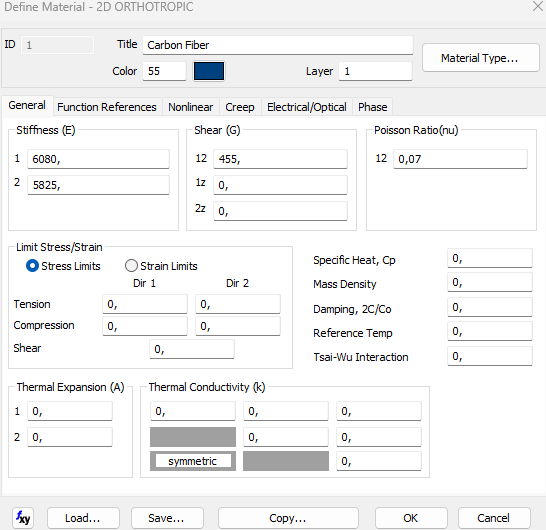

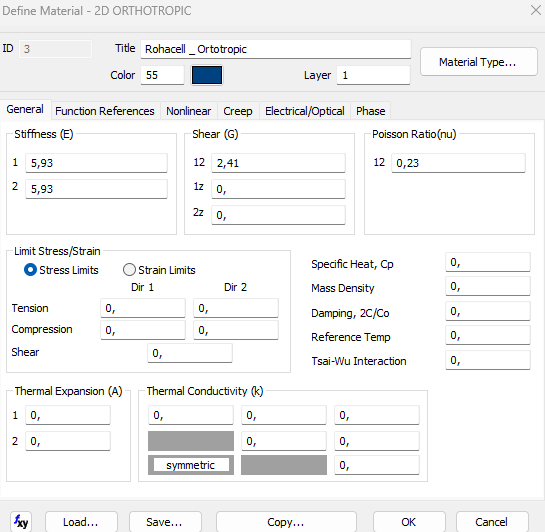

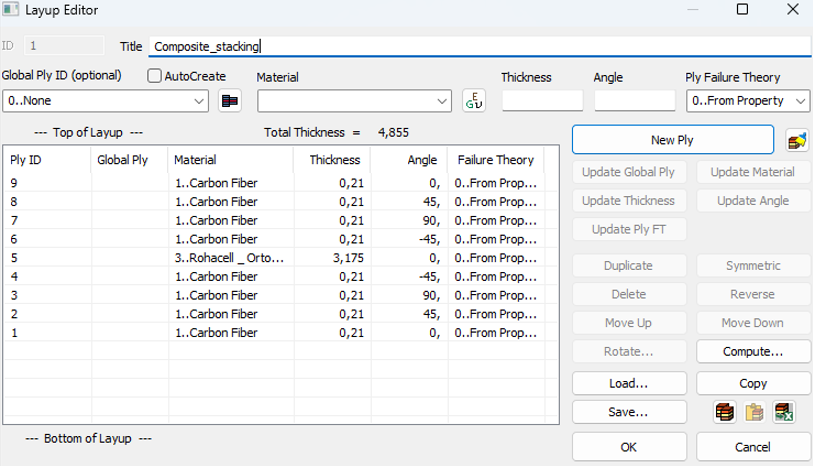

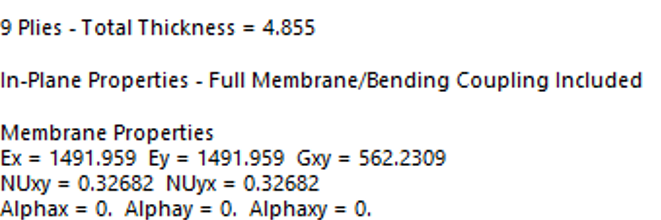

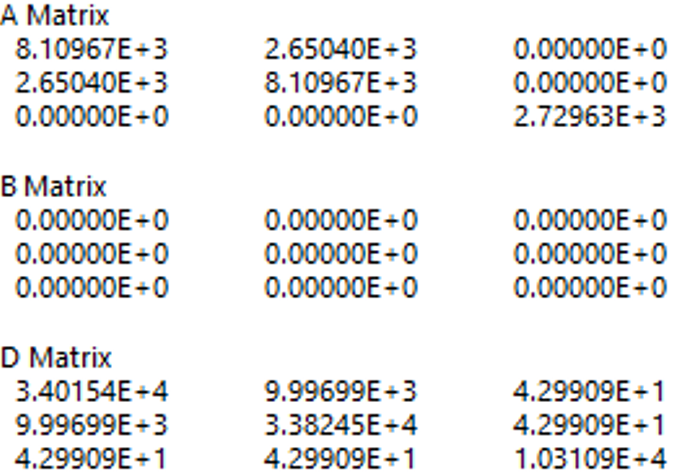

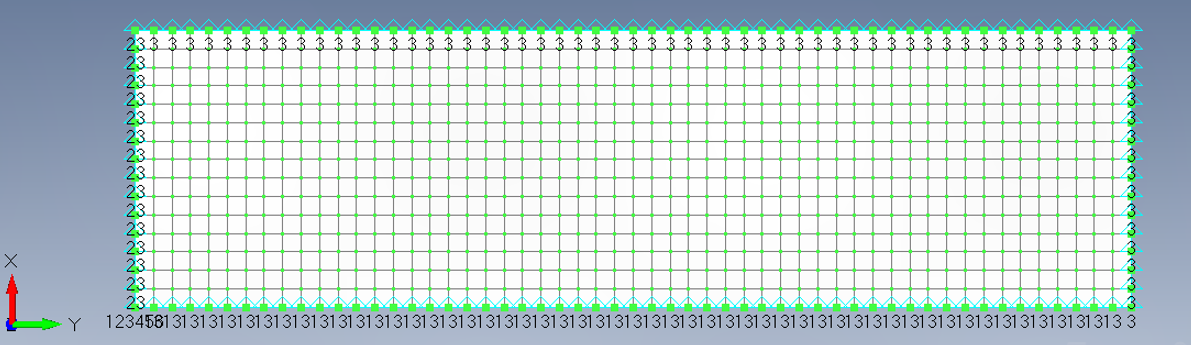

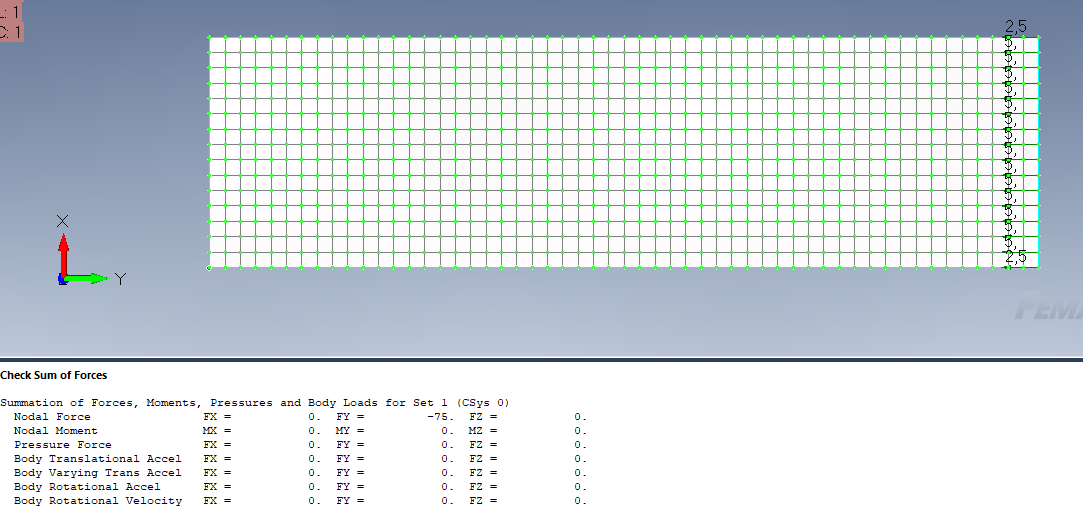

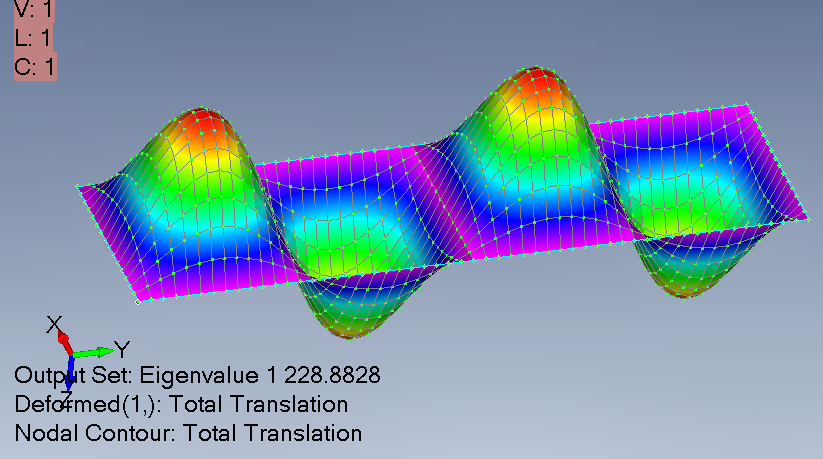